In [62]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Embeddings

Medical Abstracts Text Classification Dataset
This repository contains a medical abstracts dataset, describing 5 different classes of patient conditions. The dataset can be used for text classification. Classes are:

1. Neoplasms
2. Digestive system diseases	
3. Nervous system diseases	
4. Cardiovascular diseases	
5. General pathological conditions	


In [2]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/" + splits["test"])

In [60]:
labels_dict = {
    1: "Neoplasm",
    2: "Digestive system disease",
    3: "Nervous system disease",
    4: "Cardiovascular disease",
    5: "General pathological condition"
}
labels_array = np.array(list(labels_dict.values()))

In [3]:
df_train.head()

,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...


In [4]:
X_train = df_train['medical_abstract'].to_list()
y_train = df_train['condition_label']

X_test = df_test['medical_abstract'].to_list()
y_test = df_test['condition_label']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

len(X_train), y_train.shape, len(X_test), y_test.shape, le.classes_

(11550, (11550,), 2888, (2888,), array([1, 2, 3, 4, 5]))

In [5]:
from sklearn.dummy import DummyClassifier

In [6]:
clf = DummyClassifier(strategy="most_frequent")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.3327562326869806

## Bag-of-Words

In [7]:
vectorizer = CountVectorizer()
vectorizer

CountVectorizer()

In [8]:
X_train_enc = vectorizer.fit_transform(X_train)
X_test_enc = vectorizer.transform(X_test)

X_train_enc.shape, X_test_enc.shape

((11550, 35219), (2888, 35219))

In [9]:
X_train_enc

<11550x35219 sparse matrix of type '<class 'numpy.int64'>'
	with 1123840 stored elements in Compressed Sparse Row format>

In [10]:
vectorizer.get_feature_names_out()

array(['00', '000', '0000', ..., 'zymograms', 'zymosan', 'zzygos'],
      dtype=object)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_enc, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
model.score(X_test_enc, y_test)

0.467797783933518

## Word2Vec

In [13]:
# !pip install gensim

In [ ]:
import re

def tokenize(text):
    # Replaces every character that is not: a-z, 0-9, or whitespace with a space.
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = text.split()
    return tokens

In [15]:
tokenized_texts = [tokenize(text) for text in X_train]

print(tokenized_texts[0][:50])

['tissue', 'changes', 'around', 'loose', 'prostheses', 'a', 'canine', 'model', 'to', 'investigate', 'the', 'effects', 'of', 'an', 'antiinflammatory', 'agent', 'the', 'aseptically', 'loosened', 'prosthesis', 'provided', 'a', 'means', 'for', 'investigating', 'the', 'in', 'vivo', 'and', 'in', 'vitro', 'activity', 'of', 'the', 'cells', 'associated', 'with', 'the', 'loosening', 'process', 'in', 'seven', 'dogs', 'the', 'cells', 'were', 'isolated', 'and', 'maintained', 'in']


In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100, # embedding dimension
    window=5, # context window size
    min_count=5,  # ignore rare words
    workers=4,
    sg=1, # 1 = skip-gram, 0 = CBOW
    epochs=20
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [17]:
len(w2v_model.wv)

16383

In [18]:
w2v_model.wv.most_similar("disease", topn=10)

[('diseases', 0.5988872647285461),
 ('hippel', 0.5751314759254456),
 ('crohn', 0.564551830291748),
 ('lindau', 0.5477303862571716),
 ('legg', 0.5464467406272888),
 ('peyronie', 0.5397529006004333),
 ('erythematosus', 0.5388842821121216),
 ('mthfr', 0.5330365300178528),
 ('thyroiditis', 0.5302309989929199),
 ('involvement', 0.5128465294837952)]

In [19]:
w2v_model.wv.most_similar("cancer", topn=10)

[('cancers', 0.7971646189689636),
 ('carcinoma', 0.7234857678413391),
 ('breast', 0.7163472771644592),
 ('adenocarcinoma', 0.7013696432113647),
 ('colorectal', 0.6950269937515259),
 ('operable', 0.6812775731086731),
 ('carcinomas', 0.6696534752845764),
 ('nsclc', 0.6536808013916016),
 ('roswell', 0.6209771633148193),
 ('park', 0.6205393671989441)]

In [20]:
w2v_model.wv.most_similar("patients", topn=10)

[('who', 0.6348344087600708),
 ('whom', 0.6143625974655151),
 ('sph', 0.597321629524231),
 ('children', 0.5895660519599915),
 ('nine', 0.5888631343841553),
 ('cases', 0.5880119204521179),
 ('623', 0.5874456167221069),
 ('subjects', 0.5780882239341736),
 ('endocrinopathies', 0.5766342282295227),
 ('pseudomyxoma', 0.5735698342323303)]

In [21]:
word = "supercalifragilisticexpialidocious"

if word in w2v_model.wv:
    print(w2v_model.wv.most_similar(word, topn=10))
else:
    print(f"{word} not in vocabulary")

supercalifragilisticexpialidocious not in vocabulary


In [22]:
w2v_model.wv["diabetes"]

array([ 0.13590524, -0.3275564 ,  0.26772976,  0.25633833, -0.55165356,
       -0.6627396 , -0.06149589,  0.69970685, -0.4630453 , -0.54419726,
       -0.35778996, -0.4706524 , -0.18898009,  0.4039294 ,  0.6355829 ,
       -0.24121246,  0.5416502 , -0.29519257,  0.27560243, -0.02100574,
       -0.68417156,  0.0654092 ,  0.5579482 ,  0.6232406 ,  0.23814787,
       -0.24716042,  0.15649712,  0.6008864 ,  0.1150303 ,  0.6801644 ,
       -0.31324515, -0.3761583 , -0.06989925, -0.62061816,  0.08189368,
       -0.00615423, -0.01620837, -0.41303247, -0.45228192,  0.60265666,
       -0.01558223,  0.41163668, -0.071659  ,  0.6785008 ,  0.41826287,
       -0.19689015, -0.2523736 , -0.37708917,  0.08238792,  0.19572872,
        0.29337358, -0.5918098 ,  1.1910839 , -0.4948941 , -0.39064753,
        1.0947086 ,  0.4538267 ,  0.17528534, -0.70004076, -0.01459176,
        0.49047095, -0.01549611, -0.52373517, -0.42223084, -0.5170553 ,
       -0.04459104, -0.21442644,  0.05412346, -0.66312665,  0.91

In [23]:
w2v_model.wv["diabetes"].shape

(100,)

### Visualization with TSNE

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

#### Visualize selected words

In [25]:
selected_words = [
    "disease", "patients", "patient", "treatment", "therapy",
    "cancer", "tumor", "cell", "cells",
    "diabetes", "insulin", "glucose",
    "heart", "cardiac", "blood",
    "infection", "virus", "bacterial",
    "risk", "clinical", "study", "analysis"
]

selected_words = [w for w in selected_words if w in w2v_model.wv]

print(selected_words)

['disease', 'patients', 'patient', 'treatment', 'therapy', 'cancer', 'tumor', 'cell', 'cells', 'diabetes', 'insulin', 'glucose', 'heart', 'cardiac', 'blood', 'infection', 'virus', 'bacterial', 'risk', 'clinical', 'study', 'analysis']


In [26]:
X = np.array([w2v_model.wv[w] for w in selected_words])

tsne = TSNE(
    n_components=2,
    perplexity=min(5, len(selected_words) - 1),
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_2d = tsne.fit_transform(X)

df_vis = pd.DataFrame({
    "word": selected_words,
    "x": X_2d[:, 0],
    "y": X_2d[:, 1]
})

df_vis.head()

,word,x,y
0,disease,-8.423610,19.119959
1,patients,-3.289700,6.039580
2,patient,-12.337165,5.881993
3,treatment,12.016874,25.854197
4,therapy,15.253055,33.183659


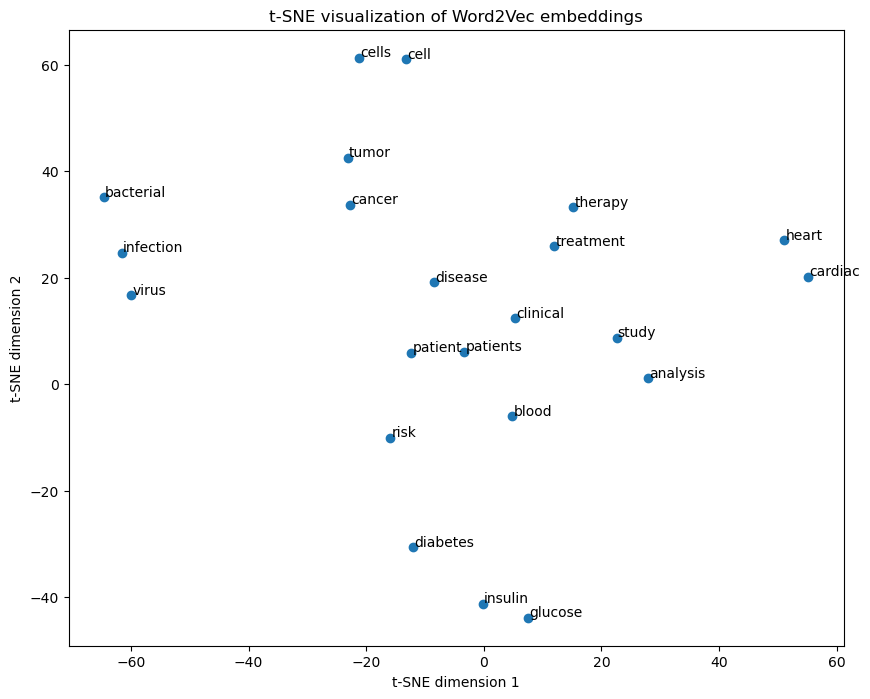

In [27]:
plt.figure(figsize=(10, 8))

plt.scatter(df_vis["x"], df_vis["y"])

for _, row in df_vis.iterrows():
    plt.text(row["x"] + 0.2, row["y"] + 0.2, row["word"], fontsize=10)

plt.title("t-SNE visualization of Word2Vec embeddings")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.show()

In [28]:
# !pip install plotly

In [29]:
import plotly.express as px

fig = px.scatter(
    df_vis,
    x="x",
    y="y",
    text="word",
    hover_name="word",
    title="t-SNE visualization of frequent Word2Vec embeddings",
    labels={
        "x": "t-SNE dimension 1",
        "y": "t-SNE dimension 2"
    },
    width=900,
    height=700
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=8)
)

fig.update_layout(
    showlegend=False
)

fig.show()

#### Visualize top 1000 most common words

In [30]:
# All words learned by Word2Vec
words = list(w2v_model.wv.index_to_key)

print(len(words))
print(words[:20])

16383
['the', 'of', 'and', 'in', 'with', 'a', 'to', 'patients', 'was', 'were', 'for', 'or', 'is', 'that', 'by', 'than', '0', '1', 'from', 'at']


In [31]:
max_words = 1000

words_subset = words[:max_words]

X_words = np.array([
    w2v_model.wv[word]
    for word in words_subset
])

print(X_words.shape)

(1000, 100)


In [32]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_2d = tsne.fit_transform(X_words)

In [33]:
df_tsne_words = pd.DataFrame({
    "word": words_subset,
    "x": X_2d[:, 0],
    "y": X_2d[:, 1]
})

df_tsne_words.head()

,word,x,y
0,the,2.015005,6.278817
1,of,2.002293,5.580187
2,and,1.284540,5.523833
3,in,0.616366,4.783891
4,with,0.823788,3.870895


In [34]:
fig = px.scatter(
    df_tsne_words,
    x="x",
    y="y",
    hover_name="word",
    title="t-SNE visualization of Word2Vec word embeddings",
    labels={
        "x": "t-SNE dimension 1",
        "y": "t-SNE dimension 2"
    },
    width=900,
    height=700
)

fig.update_traces(
    marker=dict(size=5, opacity=0.7)
)

fig.update_layout(
    showlegend=False
)

fig.show()

In [35]:
df_labels = df_tsne_words.iloc[:500]

fig = px.scatter(
    df_labels,
    x="x",
    y="y",
    text="word",
    hover_name="word",
    title="t-SNE visualization of top 500 Word2Vec word embeddings",
    labels={
        "x": "t-SNE dimension 1",
        "y": "t-SNE dimension 2"
    },
    width=900,
    height=700
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=7, opacity=0.8)
)

fig.update_layout(
    showlegend=False
)

fig.show()

### Classification
We compute the embeddings for each word in a sentence and average them to have one embedding for each sentence. This is a naive approach, more advanced models compute a sentence embedding

In [36]:
import numpy as np
from gensim.utils import simple_preprocess

def embed_text_average(text, model):
    tokens = simple_preprocess(text, deacc=True)

    vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [37]:
X_train_w2v = np.array([
    embed_text_average(text, w2v_model)
    for text in X_train
])

X_test_w2v = np.array([
    embed_text_average(text, w2v_model)
    for text in X_test
])

In [38]:
X_train_w2v.shape, X_test_w2v.shape

((11550, 100), (2888, 100))

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_w2v, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [41]:
model.score(X_test_w2v, y_test)

0.5924515235457064

In [50]:
tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_2d = tsne.fit_transform(X_train_w2v[::10])

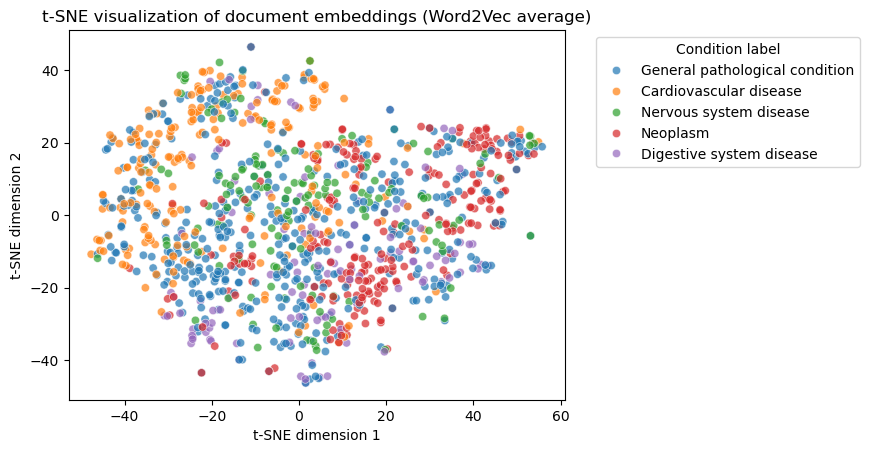

In [63]:
import seaborn as sns

sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_array[y_train[::10]], palette="tab10", alpha=0.7)
plt.title("t-SNE visualization of document embeddings (Word2Vec average)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(title="Condition label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Bert

In [69]:
# !pip install transformers

In [72]:
import numpy as np
import torch

from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

In [82]:
model_name = "distilbert-base-uncased"  # bigger, but can be slow on CPU
model_name = "prajjwal1/bert-tiny"  # smaller, faster, but less accurate

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
bert_model = bert_model.to(device)

bert_model.eval()

device

config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

'mps'

In [83]:
def embed_texts_transformer(texts, tokenizer, model, batch_size=16, max_length=256):
    all_embeddings = []

    for start in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            outputs = model(**encoded)

        last_hidden_state = outputs.last_hidden_state

        # DistilBERT also uses the first token as a sequence representation
        cls_embeddings = last_hidden_state[:, 0, :]

        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [84]:
%%time

# warning: this can take a while on CPU, consider using a GPU if available

X_train_small = X_train
y_train_small = y_train

X_test_small = X_test
y_test_small = y_test

X_train_distilbert = embed_texts_transformer(
    X_train_small,
    tokenizer,
    bert_model,
    batch_size=32,
    max_length=256
)

X_test_distilbert = embed_texts_transformer(
    X_test_small,
    tokenizer,
    bert_model,
    batch_size=32,
    max_length=256
)

X_train_distilbert.shape, X_test_distilbert.shape

  0%|          | 0/361 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

CPU times: user 14.1 s, sys: 1.32 s, total: 15.4 s
Wall time: 14 s


((11550, 128), (2888, 128))

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_distilbert, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [86]:
model.score(X_test_distilbert, y_test)

0.5024238227146814

In [93]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_2d = tsne.fit_transform(X_train_distilbert[::10])

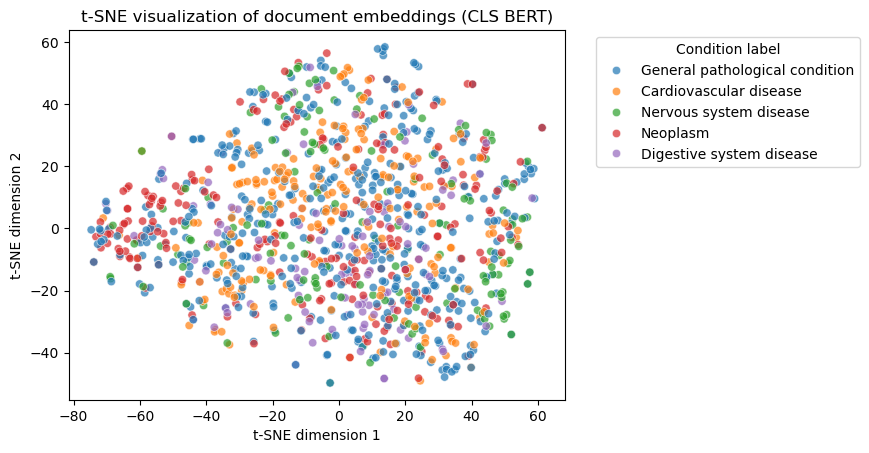

In [94]:
import seaborn as sns

sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_array[y_train[::10]], palette="tab10", alpha=0.7)
plt.title("t-SNE visualization of document embeddings (CLS BERT)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(title="Condition label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Exercise
Analyze the 20newsgroup dataset using Bag-of-Words, Word2Vec, and BERT

In [ ]:
from sklearn.datasets import fetch_20newsgroups

In [ ]:
categories = [
    "sci.med",
    "sci.space",
    "rec.sport.baseball",
    "talk.politics.misc"
]

train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    random_state=42
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    random_state=42
)

X_train_ex = train_data.data
y_train_ex = train_data.target

X_test_ex = test_data.data
y_test_ex = test_data.target

labels_array_ex = train_data.target_names

len(X_train_ex), len(X_test_ex), labels_array_ex

(2249,
 1497,
 ['rec.sport.baseball', 'sci.med', 'sci.space', 'talk.politics.misc'])

In [102]:
print(X_train_ex[0])

  Bingo.
 Nothing evil at all. There's no actual harm in what they're doing, only
how they represent it.

 -----------------------------------------------------------------
 .sig files are like strings ... every yo-yo's got one.
